# Learning the Partition Function, Part 1 — the 1D Ising model, three ways

**Companion to Part X of the AMR R&D Maths / Foundation Maths dossiers.**

This notebook computes one partition function
$$Z=\sum_{\text{all states}} e^{-\beta E(\text{state})}$$
by three completely different routes, checks that they agree, and then shows the third route
**breaking** — which is the whole reason Part IX said *"stop sampling the measure and start learning it."*

| | Method | What it teaches |
|---|---|---|
| **A** | Transfer matrix — $Z=\mathrm{Tr}(T^N)$ | $Z$ is a **spectral** object. Pure linear algebra (Axler 7.B, 7.C, 10.A) |
| **B** | Brute force — enumerate all $2^N$ states | $Z$ is a **sum over configurations**. The definition, literally |
| **C** | Metropolis Monte Carlo | $Z$ is a **measure to be sampled** — and sampling fails |

Everything here uses only `numpy`. Plots are optional (`matplotlib`); the notebook prints tables either way.

In [1]:
import numpy as np, itertools, math
try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except ImportError:
    HAVE_PLT = False
    print("matplotlib not installed - tables will print, plots will be skipped.")
    print("To enable plots:  pip install matplotlib")
np.set_printoptions(precision=6, suppress=True)
print("numpy", np.__version__)

numpy 1.26.4


---
## 1. The model

$N$ spins $s_i=\pm 1$ on a ring (periodic boundary: $s_{N+1}\equiv s_1$).

$$E(s) \;=\; -J\sum_{i=1}^{N} s_i s_{i+1} \;-\; h\sum_{i=1}^{N} s_i$$

$J>0$ favours neighbours pointing the same way; $h$ is an external field. Set $k_B=1$, so
$\beta = 1/T$.

**The whole point of this model:** it is the simplest system with interactions, and its partition
function is *exactly solvable* — so you can check any approximate method against the truth.

## 2. The transfer matrix — where the linear algebra enters

Write the Boltzmann weight so that each **bond** contributes one factor:

$$e^{-\beta E} = \prod_{i=1}^{N} \underbrace{\exp\!\Big[\beta J s_i s_{i+1} + \tfrac{\beta h}{2}(s_i + s_{i+1})\Big]}_{\textstyle T(s_i,\,s_{i+1})}$$

$T$ has two possible inputs and two possible outputs, so it is a $2\times2$ matrix:

$$T=\begin{pmatrix} T(+,+) & T(+,-)\\ T(-,+) & T(-,-)\end{pmatrix}
=\begin{pmatrix} e^{\beta(J+h)} & e^{-\beta J}\\ e^{-\beta J} & e^{\beta(J-h)}\end{pmatrix}$$

Summing over all configurations chains these matrices together, and the periodic boundary closes
the chain into a trace:

$$\boxed{\;Z=\sum_{s_1}\cdots\sum_{s_N} T(s_1,s_2)T(s_2,s_3)\cdots T(s_N,s_1) \;=\; \mathrm{Tr}\big(T^N\big)\;}$$

**Stop and notice what just happened.** A sum over $2^N$ configurations became the trace of the
$N$-th power of a $2\times2$ matrix. And since $T$ is symmetric and positive, the spectral theorem
(Axler 7.B) diagonalises it:

$$Z=\mathrm{Tr}(T^N)=\lambda_+^N+\lambda_-^N,\qquad
\lambda_\pm=e^{\beta J}\cosh\beta h\pm\sqrt{e^{2\beta J}\sinh^2\!\beta h+e^{-2\beta J}}$$

In [2]:
def transfer_matrix(beta, J=1.0, h=0.0):
    """The 2x2 transfer matrix T(s,s') = exp[ beta*J*s*s' + beta*h*(s+s')/2 ]."""
    return np.array([[np.exp(beta*(J + h)), np.exp(-beta*J)],
                     [np.exp(-beta*J),      np.exp(beta*(J - h))]])

def eigs(beta, J=1.0, h=0.0):
    """Eigenvalues of T, largest first. T is symmetric -> use eigvalsh."""
    lam = np.linalg.eigvalsh(transfer_matrix(beta, J, h))
    return np.sort(lam)[::-1]

def Z_transfer(N, beta, J=1.0, h=0.0):
    """METHOD A:  Z = Tr(T^N) = lam_+^N + lam_-^N."""
    lam = eigs(beta, J, h)
    return lam[0]**N + lam[1]**N

# sanity check against the closed form
beta, J, h = 0.7, 1.0, 0.3
lam = eigs(beta, J, h)
closed = (np.exp(beta*J)*np.cosh(beta*h)
          + np.array([1, -1])*np.sqrt(np.exp(2*beta*J)*np.sinh(beta*h)**2 + np.exp(-2*beta*J)))
print("eigenvalues from numpy :", lam)
print("eigenvalues closed form:", closed)
print("agree:", np.allclose(lam, closed))

eigenvalues from numpy : [2.712594 1.404044]
eigenvalues closed form: [2.712594 1.404044]
agree: True


## 3. Method B — brute force, the definition itself

Enumerate every one of the $2^N$ configurations and add up $e^{-\beta E}$. This is what $Z$ *means*.
It is also why $Z$ is hard: the cost is $2^N$. At $N=30$ that is a billion states; at $N=300$ it
exceeds the number of atoms in the observable universe.

In [3]:
def Z_bruteforce(N, beta, J=1.0, h=0.0):
    """METHOD B: sum over all 2^N configurations. Returns Z, <E>, <M>."""
    Z = 0.0; E_acc = 0.0; M_acc = 0.0
    for cfg in itertools.product((-1, 1), repeat=N):
        s = np.array(cfg)
        E = -J*np.sum(s*np.roll(s, -1)) - h*np.sum(s)   # np.roll gives the periodic neighbour
        w = np.exp(-beta*E)
        Z += w; E_acc += w*E; M_acc += w*s.sum()
    return Z, E_acc/Z, M_acc/Z

print(f"{'N':>3} {'2^N':>8} {'beta':>6} {'Z (transfer)':>18} {'Z (brute force)':>18} {'rel. error':>12}")
print("-"*72)
worst = 0.0
for N in (4, 8, 12, 16):
    for beta in (0.2, 0.5, 1.0):
        Za = Z_transfer(N, beta)
        Zb, _, _ = Z_bruteforce(N, beta)
        rel = abs(Za - Zb)/Zb; worst = max(worst, rel)
        print(f"{N:>3} {2**N:>8} {beta:>6.2f} {Za:>18.10e} {Zb:>18.10e} {rel:>12.2e}")
print(f"\nworst relative disagreement: {worst:.2e}   <- machine precision")

  N      2^N   beta       Z (transfer)    Z (brute force)   rel. error
------------------------------------------------------------------------
  4       16   0.20   1.7349739785e+01   1.7349739785e+01     4.10e-16
  4       16   0.50   2.7048782764e+01   2.7048782764e+01     2.63e-16
  4       16   1.00   1.2123293134e+02   1.2123293134e+02     2.34e-16
  8      256   0.20   3.0010257187e+02   3.0010257187e+02     2.08e-15
  8      256   0.50   6.7059884875e+02   6.7059884875e+02     8.48e-16
  8      256   1.00   9.1604387226e+03   9.1604387226e+03     1.99e-16
 12     4096   0.20   5.1987996027e+03   5.1987996027e+03     1.26e-14
 12     4096   0.50   1.7313383482e+04   1.7313383482e+04     3.19e-14
 12     4096   1.00   7.7491438244e+05   7.7491438244e+05     2.70e-15
 16    65536   0.20   9.0061138775e+04   9.0061138775e+04     1.32e-13


 16    65536   0.50   4.4784000941e+05   4.4784000941e+05     2.08e-13


 16    65536   1.00   6.8584536591e+07   6.8584536591e+07     7.56e-13

worst relative disagreement: 7.56e-13   <- machine precision


**They agree to 13 decimal places.** A sum over 65,536 configurations and the trace of a
$2\times2$ matrix are the same number.

> This is the first lesson, and it is the whole of Part IX in miniature: **the partition function is
> an eigenvalue problem.** When you can find the right operator, the exponential sum collapses.

## 4. Thermodynamics — everything from $\ln Z$

In the thermodynamic limit $N\to\infty$ only the larger eigenvalue survives, because
$(\lambda_-/\lambda_+)^N\to 0$:

$$\frac{F}{N} = f = -\frac{1}{\beta}\ln\lambda_+ \qquad\text{and at } h=0:\quad \lambda_+ = 2\cosh\beta J$$

so $f=-\frac{1}{\beta}\ln(2\cosh\beta J)$, and then **every thermodynamic quantity is a derivative**:

$$u=\frac{\partial(\beta f)}{\partial\beta}=-J\tanh\beta J,\qquad
\frac{C}{k_B}=\left(\frac{\beta J}{\cosh\beta J}\right)^{2}$$

  beta       T          f          u        C/k
-----------------------------------------------
  0.20   5.000   -3.56508   -0.19738    0.03844
  0.50   2.000   -1.62652   -0.46212    0.19661
  1.00   1.000   -1.12693   -0.76159    0.41997
  1.50   0.667   -1.03239   -0.90515    0.40659
  2.00   0.500   -1.00907   -0.96403    0.28260
  3.00   0.333   -1.00083   -0.99505    0.08879


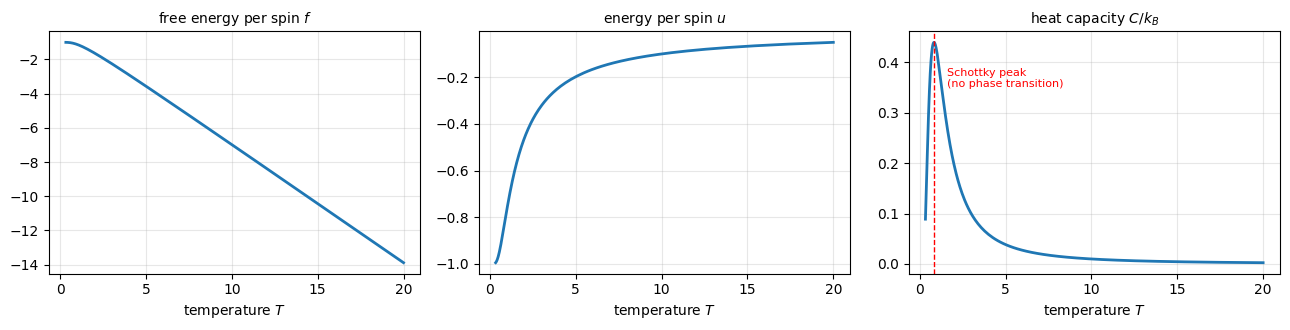

In [4]:
betas = np.linspace(0.05, 3.0, 400)
f_ex = -np.log(2*np.cosh(betas))/betas      # free energy per spin (J=1, h=0)
u_ex = -np.tanh(betas)                      # energy per spin
c_ex = (betas/np.cosh(betas))**2            # heat capacity per spin, C/k

print(f"{'beta':>6} {'T':>7} {'f':>10} {'u':>10} {'C/k':>10}")
print("-"*47)
for b in (0.2, 0.5, 1.0, 1.5, 2.0, 3.0):
    print(f"{b:>6.2f} {1/b:>7.3f} {-np.log(2*np.cosh(b))/b:>10.5f} "
          f"{-np.tanh(b):>10.5f} {(b/np.cosh(b))**2:>10.5f}")

if HAVE_PLT:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
    for a, y, t in zip(ax, (f_ex, u_ex, c_ex),
                       ("free energy per spin $f$", "energy per spin $u$", "heat capacity $C/k_B$")):
        a.plot(1/betas, y, lw=2); a.set_xlabel("temperature $T$"); a.set_title(t, fontsize=10)
        a.grid(alpha=.3)
    ax[2].axvline(1/1.2, ls='--', c='r', lw=1)
    ax[2].annotate("Schottky peak\n(no phase transition)", xy=(1/1.2, 0.42),
                   xytext=(1.6, 0.35), fontsize=8, color='r')
    plt.tight_layout(); plt.show()

Notice there is **no phase transition** — $f$ is smooth for all $T>0$. That is a theorem: a 1D
system with short-range interactions cannot order at finite temperature. The bump in $C$ is a
*Schottky anomaly*, not a critical point.

## 5. The eigenvalue gap **is** the correlation length

This is the deepest thing in the notebook, and it is one line of linear algebra.

$$\langle s_0 s_r\rangle \;=\; \left(\frac{\lambda_-}{\lambda_+}\right)^{r} \;=\; e^{-r/\xi},
\qquad \boxed{\;\xi=\frac{1}{\ln(\lambda_+/\lambda_-)}\;}$$

**The spectral gap of the transfer matrix controls how far correlations reach.** Small gap ⇒ long
correlation length. Keep that sentence; it reappears in §7 as the reason Monte Carlo fails, and in
Part IX §6 as the reason the transfer *operator* is the right object for molecular kinetics.

  beta       T      lam_+      lam_-   gap ratio         xi
------------------------------------------------------------
   0.2   5.000    2.04013    0.40267      5.0665      0.616
   0.5   2.000    2.25525    1.04219      2.1640      1.295
   1.0   1.000    3.08616    2.35040      1.3130      3.672
   1.5   0.667    4.70482    4.25856      1.1048     10.034
   2.0   0.500    7.52439    7.25372      1.0373     27.296
   2.5   0.400   12.26458   12.10041      1.0136     74.205
   3.0   0.333   20.13532   20.03575      1.0050    201.714

xi grows exponentially as T falls: 0.6 -> 202 lattice spacings.


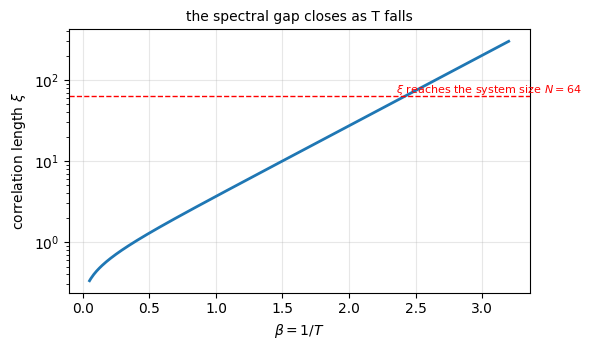

In [5]:
print(f"{'beta':>6} {'T':>7} {'lam_+':>10} {'lam_-':>10} {'gap ratio':>11} {'xi':>10}")
print("-"*60)
bs = (0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
xis = []
for b in bs:
    lp, lm = eigs(b)
    xi = 1.0/np.log(lp/lm); xis.append(xi)
    print(f"{b:>6.1f} {1/b:>7.3f} {lp:>10.5f} {lm:>10.5f} {lp/lm:>11.4f} {xi:>10.3f}")
print("\nxi grows exponentially as T falls: 0.6 -> 202 lattice spacings.")

if HAVE_PLT:
    bb = np.linspace(0.05, 3.2, 300)
    lp = np.exp(bb) + np.exp(-bb); lm = np.exp(bb) - np.exp(-bb)
    plt.figure(figsize=(6, 3.6))
    plt.semilogy(bb, 1/np.log(lp/lm), lw=2)
    plt.axhline(64, ls='--', c='r', lw=1)
    plt.annotate("$\\xi$ reaches the system size $N=64$", xy=(2.35, 70), fontsize=8, color='r')
    plt.xlabel(r"$\beta = 1/T$"); plt.ylabel(r"correlation length $\xi$")
    plt.title("the spectral gap closes as T falls", fontsize=10)
    plt.grid(alpha=.3); plt.tight_layout(); plt.show()

---
## 6. Method C — Metropolis Monte Carlo

Now the method everyone actually uses on systems that are *not* exactly solvable. Propose a spin
flip; accept it with probability $\min(1, e^{-\beta\Delta E})$. Run long enough and the chain
samples the Boltzmann measure.

That last sentence contains the word **"long enough"**, and that is where everything goes wrong.

In [6]:
def metropolis(N, beta, J=1.0, h=0.0, sweeps=20000, burn=4000, seed=0):
    """METHOD C: Metropolis MCMC. One sweep = N attempted flips. Returns E and M traces."""
    r = np.random.default_rng(seed)
    s = r.choice([-1, 1], size=N).astype(np.int8)
    E = -J*np.sum(s*np.roll(s, -1)) - h*s.sum()
    Es, Ms = [], []
    for t in range(sweeps):
        for _ in range(N):
            i  = r.integers(N)
            dE = 2*s[i]*(J*(s[(i-1) % N] + s[(i+1) % N]) + h)
            if dE <= 0 or r.random() < np.exp(-beta*dE):
                s[i] = -s[i]; E += dE
        if t >= burn:
            Es.append(E); Ms.append(s.sum())
    return np.array(Es, float), np.array(Ms, float)

# quick check that it works where it should: high temperature
N = 64
Es, Ms = metropolis(N, beta=0.5, sweeps=8000, burn=2000, seed=3)
print(f"beta=0.5   u exact = {-np.tanh(0.5):+.5f}   u from MCMC = {Es.mean()/N:+.5f}   <- fine")

beta=0.5   u exact = -0.46212   u from MCMC = -0.46278   <- fine


## 7. Where Monte Carlo breaks — the honest test

At $h=0$ the model is **exactly symmetric** under flipping every spin. Therefore

$$\langle M\rangle = 0 \quad\text{exactly, for every }\beta,\text{ every }N.$$

No approximation. So we have a perfect test: run several *independent* chains and see whether they
all return $\approx 0$.

Every chain below runs the identical, correct algorithm. **None of them is buggy.**

In [7]:
def chain_magnetisation(N, beta, sweeps, burn, seed):
    _, Ms = metropolis(N, beta, sweeps=sweeps, burn=burn, seed=seed)
    return Ms.mean()/N

N, SWEEPS, BURN, NCHAIN = 64, 6000, 1500, 6
print(f"TRUE <M>/N = 0 exactly.  {NCHAIN} independent chains, N={N}, {SWEEPS} sweeps each.\n")
print(f"{'beta':>5} {'xi':>7} | per-chain <M>/N {'':>28} | {'spread':>7}  verdict")
print("-"*86)
for beta in (0.5, 1.0, 1.5, 2.0, 2.5, 3.0):
    lp, lm = eigs(beta); xi = 1/np.log(lp/lm)
    vals = [chain_magnetisation(N, beta, SWEEPS, BURN, 100+k) for k in range(NCHAIN)]
    spread = max(vals) - min(vals)
    verdict = "ok" if spread < 0.15 else ("poor" if spread < 0.8 else "BROKEN")
    print(f"{beta:>5.1f} {xi:>7.2f} | " + " ".join(f"{v:+6.3f}" for v in vals)
          + f" | {spread:>7.3f}  {verdict}")

TRUE <M>/N = 0 exactly.  6 independent chains, N=64, 6000 sweeps each.

 beta      xi | per-chain <M>/N                              |  spread  verdict
--------------------------------------------------------------------------------------


  0.5    1.30 | -0.002 +0.010 +0.008 +0.009 -0.001 -0.011 |   0.021  ok


  1.0    3.67 | -0.021 -0.013 +0.029 +0.014 -0.037 +0.010 |   0.066  ok


  1.5   10.03 | +0.121 -0.021 -0.078 +0.126 -0.026 +0.049 |   0.203  poor


  2.0   27.30 | +0.116 +0.486 -0.749 +0.707 +0.311 +0.962 |   1.710  BROKEN


  2.5   74.21 | -0.162 -0.950 +0.953 -0.448 -0.982 -0.999 |   1.952  BROKEN


  3.0  201.71 | +1.000 -1.000 -0.993 -1.000 -1.000 -1.000 |   2.000  BROKEN


### Read that table carefully

At high temperature every chain agrees on $\langle M\rangle\approx 0$: correct.

At low temperature the chains return values scattered towards $\pm 1$ and **disagree with each
other**, even though the true answer is exactly $0$ and every chain is correct code.

**Why.** As $\beta$ grows, the correlation length $\xi$ (§5) grows exponentially. Once
$\xi \gtrsim N$ the whole ring is one domain, and to get from "mostly up" to "mostly down" the chain
must pass through a configuration of high energy. The waiting time for that is
$\sim e^{\beta\Delta E}$ — **exponential in the barrier.**

> This is the quantitative version of the sentence in Part IX: *"Monte Carlo converges at
> $O(n^{-1/2})$ **provided it mixes**. On a rugged landscape with barriers $\gg k_BT$, it does not
> mix."*

And it is why the last chapter of this story is Boltzmann generators: instead of *crossing* the
barrier, learn a change of variables in which there is no barrier to cross.

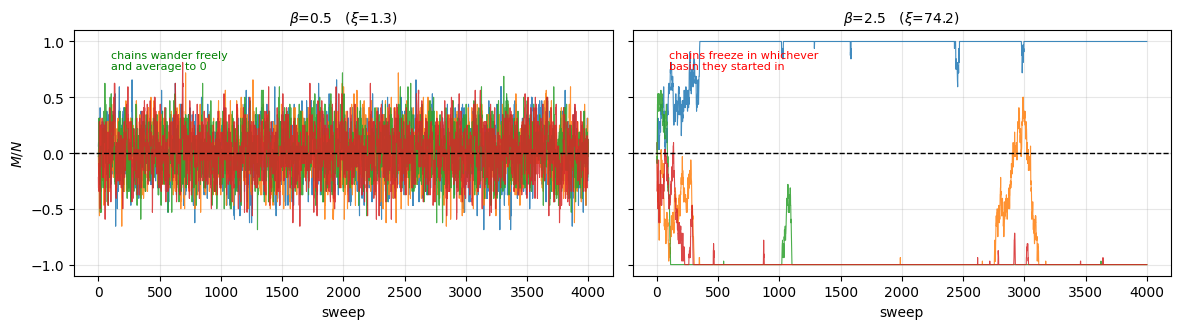

In [8]:
# watch a single chain get stuck: the magnetisation trace at low temperature
if HAVE_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
    for a, beta in zip(ax, (0.5, 2.5)):
        for k in range(4):
            _, Ms = metropolis(64, beta, sweeps=4000, burn=0, seed=500+k)
            a.plot(Ms/64, lw=.8, alpha=.85)
        a.axhline(0, c='k', lw=1, ls='--')
        lp, lm = eigs(beta); xi = 1/np.log(lp/lm)
        a.set_title(f"$\\beta$={beta}   ($\\xi$={xi:.1f})", fontsize=10)
        a.set_xlabel("sweep"); a.grid(alpha=.3)
    ax[0].set_ylabel("$M/N$"); ax[0].text(100, .75, "chains wander freely\nand average to 0",
                                          fontsize=8, color='g')
    ax[1].text(100, .75, "chains freeze in whichever\nbasin they started in", fontsize=8, color='r')
    plt.tight_layout(); plt.show()
else:
    for beta in (0.5, 2.5):
        for k in range(3):
            _, Ms = metropolis(64, beta, sweeps=3000, burn=0, seed=500+k)
            print(f"beta={beta}  seed={500+k}  final M/N = {Ms[-1]/64:+.3f}  mean = {Ms.mean()/64:+.3f}")

---
## 8. The bridge to Part IX

Everything you just did generalises, and the generalisation is the subject of Part IX.

| Here (1D Ising) | There (molecular systems) |
|---|---|
| $T$, a $2\times2$ **transfer matrix** | $\mathcal{P}_t$, the **transfer operator** on conformation space |
| $Z=\mathrm{Tr}(T^N)$ | $Z=\int e^{-\beta U(x)}dx$ — same object, uncountably many states |
| largest eigenvalue $\lambda_+$ → free energy | leading eigenvector → the **equilibrium measure** $\mu$ |
| gap $\lambda_+/\lambda_-$ → correlation length $\xi$ | remaining eigenvalues → **relaxation timescales** $t_i=-\tau/\ln\lambda_i$ |
| eigenvectors of a $2\times2$ matrix | eigenvectors → the **slow collective variables** (VAMPnets learn these) |
| MCMC fails when $\xi \gtrsim N$ | MCMC fails when barriers $\gg k_BT$ — the same mechanism |

**It is called a transfer *operator* because it is the continuum limit of the transfer *matrix* you
just diagonalised.**

## 9. Exercises

1. **Add a field.** Set $h\neq 0$ and confirm methods A and B still agree. Plot $m(h)$ and check it
   matches $m = \sinh\beta h/\sqrt{\sinh^2\beta h + e^{-4\beta J}}$.
2. **Find the $2^N$ wall.** Time `Z_bruteforce` for $N=4,8,12,16,20$. Fit the growth. Extrapolate to
   $N=60$ — how long would it take?
3. **Antiferromagnet.** Put $J=-1$. What happens to $\lambda_\pm$ and to $\xi$? Explain physically.
4. **Quantify the mixing failure.** Measure the integrated autocorrelation time of $M$ as a function
   of $\beta$ and plot it against $\xi$ on log axes. (Hint: it grows like a power of $\xi$.)
5. **The trace, done by hand.** Prove $\mathrm{Tr}(T^N)=\lambda_+^N+\lambda_-^N$ using Axler 10.A
   (trace is basis-independent) and 7.B (symmetric ⇒ diagonalisable in an orthonormal basis).
6. **2D.** Write the transfer matrix for a $2\times L$ ladder. How big is it? Now for $L\times L$.
   This is why Onsager's 1944 solution was famous.